## The code for Industrial-Grade Visualization in Readme
### Charton
```rust
use charton::prelude::*;
use polars::prelude::*;
use std::error::Error;

fn main() -> Result<(), Box<dyn Error>> {
    // The historical data
    let global = df!(
        "temperature" => &[10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
        "zero" => &[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        "growth" => &[2, 5, 12, 25, 40, 60, 85, 95, 98, 99]
    )?;
    
    // The sample data
    let sample = df!(
        "temperature" => &[11, 18, 25, 30, 37],
        "growth" => &[3, 8, 20, 41, 65]
    )?;

    let points = Chart::build(&sample)?
        .mark_point()?.configure_point(|p| p.with_stroke("white").with_size(6.0).with_stroke_width(1.0))
        .encode((x("temperature"), y("growth"), color("growth")))?;

    let rules = Chart::build(&global)?
        .mark_rule()?.configure_rule(|r| r.with_opacity(0.8).with_stroke_width(32.0))
        .encode((x("temperature"), y("zero"), y2("growth"), color("growth")))?;

    rules.and(points)
        .with_y_label("growth")
        .with_x_expand(Expansion { mult: (0.1, 0.1), add: (0.0, 0.0) })
        .with_y_expand(Expansion { mult: (0.0, 0.1), add: (0.0, 0.0) })
        .save("industry_charton.svg")?;

    Ok(())
}
```

**Altair:**
```python
import pandas as pd
import altair as alt

# 1. Data Preparation
# Historical baseline: Broad range [10, 50]
global_df = pd.DataFrame({
    "temperature": [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    "zero": [0] * 10,
    "growth": [2, 5, 12, 25, 40, 60, 85, 95, 98, 99]
})

# Measured sample: Narrow range [11, 37]
sample_df = pd.DataFrame({
    "temperature": [11, 18, 25, 30, 37],
    "growth": [3, 8, 20, 41, 65]
})

# 2. Background Layer (Rules)
# Using mark_bar to simulate Charton's heavy-duty rules (stroke_width=46)
rules = alt.Chart(global_df).mark_bar(
    opacity=0.8,
    binSpacing=0,
    width=30,
    strokeWidth=46
).encode(
    x=alt.X('temperature:Q'),
    y=alt.Y('zero:Q', title='growth'), # Set Y-axis label here
    y2='growth:Q',
    color=alt.Color('growth:Q', scale=alt.Scale(scheme='viridis'))
)

# 3. Foreground Layer (Samples)
# Enforcing visual differentiation with white strokes and filled points
points = alt.Chart(sample_df).mark_point(
    filled=True,
    size=130,      
    stroke='white',
    strokeWidth=1  
).encode(
    x='temperature:Q',
    y='growth:Q',
    color=alt.Color('growth:Q', scale=alt.Scale(scheme='viridis'))
)

# 4. Layer Composition & Scale Arbitration
# Altair automatically reconciles the color scales to ensure semantic consistency
chart = (rules + points).properties(
    width=360*0.9,
    height=320*0.9*0.9
).configure_axis(
    titleFontSize=12
).resolve_scale(
    color='shared' # Ensure both layers use the same global color mapping
)

# Save as SVG
chart.save('industry_altair.svg')

**Echarts** (run from https://echarts.apache.org/examples/zh/editor.html):
```JavaScript
// ECharts Logic: No automatic arbitration, must define manual limits
const globalData = [[10, 2], [15, 5], [20, 12], [25, 25], [30, 40], [35, 60], [40, 85], [45, 95], [50, 98], [55, 99]];
const sampleData = [[11, 3], [18, 8], [25, 20], [30, 41], [37, 65]];

option = {
    xAxis: { 
        type: 'value',
        name: 'temperature',
        scale: true,
        boundaryGap: ['0.5%', '0.5%'],
        axisLabel: {
              fontSize: 16,
              color: '#333'
        },
        nameTextStyle: {
            fontSize: 18
        }
    },

    yAxis: {
        type: 'value',
        name: 'growth',
        scale: true,
        axisLabel: {
            fontSize: 16
        },
        nameTextStyle: {
            fontSize: 18
        }
    },
    // This is the "Engine" - You MUST lock the range manually
    visualMap: {
        min: 0,
        max: 100,
        dimension: 1, // Map to Y-axis
        calculable: true,
        inRange: { color: ['#440154', '#21918c', '#fde725'] }, // Viridis
        right: 10,
        top: 'center'
    },
    series: [
        {
            // Background "Rules" (simulated via thick Bars)
            type: 'bar',
            data: globalData,
            barWidth: 46.1, // Matching your stroke_width
            itemStyle: { opacity: 0.8 }
        },
        {
            // Measured Points
            type: 'scatter',
            data: sampleData,
            symbolSize: 15,
            itemStyle: {
                borderColor: '#fff',
                borderWidth: 1
            }
        }
    ]
};// ECharts Logic: No automatic arbitration, must define manual limits
const globalData = [[10, 2], [15, 5], [20, 12], [25, 25], [30, 40], [35, 60], [40, 85], [45, 95], [50, 98], [55, 99]];
const sampleData = [[11, 3], [18, 8], [25, 20], [30, 41], [37, 65]];

option = {
    xAxis: { 
        type: 'value',
        name: 'temperature',
        scale: true,
        boundaryGap: ['0.5%', '0.5%'],
        axisLabel: {
              fontSize: 16,
              color: '#333'
        },
        nameTextStyle: {
            fontSize: 18
        }
    },

    yAxis: {
        type: 'value',
        name: 'growth',
        scale: true,
        axisLabel: {
            fontSize: 16
        },
        nameTextStyle: {
            fontSize: 18
        }
    },
    // This is the "Engine" - You MUST lock the range manually
    visualMap: {
        min: 0,
        max: 100,
        dimension: 1, // Map to Y-axis
        calculable: true,
        inRange: { color: ['#440154', '#21918c', '#fde725'] }, // Viridis
        right: 10,
        top: 'center'
    },
    series: [
        {
            // Background "Rules" (simulated via thick Bars)
            type: 'bar',
            data: globalData,
            barWidth: 46.1, // Matching your stroke_width
            itemStyle: { opacity: 0.8 }
        },
        {
            // Measured Points
            type: 'scatter',
            data: sampleData,
            symbolSize: 15,
            itemStyle: {
                borderColor: '#fff',
                borderWidth: 1
            }
        }
    ]
};

**Ggplot2**:
```r
library(ggplot2)

# 1. Data Preparation
global_df <- data.frame(
  temperature = c(10, 15, 20, 25, 30, 35, 40, 45, 50, 55),
  zero = 0,
  growth = c(2, 5, 12, 25, 40, 60, 85, 95, 98, 99)
)

sample_df <- data.frame(
  temperature = c(11, 18, 25, 30, 37),
  growth = c(3, 8, 20, 41, 65)
)

# 2. Plotting (The "All-Color" Method)
p <- ggplot() +
  # Layer 1: Background Rules (Heavy Lines)
  # We use geom_linerange because it only uses 'color', not 'fill'
  geom_linerange(
    data = global_df,
    aes(x = temperature, ymin = zero, ymax = growth, color = growth),
    linewidth = 13, # Absolute thickness in mm/pt
    alpha = 0.8
  ) +
  
  # Layer 2: White "Stroke" for points
  # Draw a slightly larger white point first (not mapped to color)
  geom_point(
    data = sample_df,
    aes(x = temperature, y = growth),
    color = "white",
    size = 4.0
  ) +
  
  # Layer 3: Foreground Points
  # Now map 'color' to growth - this will merge with the linerange legend
  geom_point(
    data = sample_df,
    aes(x = temperature, y = growth, color = growth),
    size = 3.0
  ) +
  
  # 3. Synchronize Scale
  # Since EVERY mapped layer uses 'color = growth', merging is 100% guaranteed
  scale_color_viridis_c(option = "viridis", name = "growth") +
  
  # 4. Layout
  scale_x_continuous(expand = expansion(mult = c(0.1, 0.1))) +
  labs(y = "growth", x = "temperature") +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )


ggsave("E:/industry_ggplot2.svg", p, width = 5.5, height = 3.6, units = "in", dpi = 100)
```


In [ ]:
:dep charton = {path = "E:/charton"}

In [ ]:
:dep polars = { version="0.49.1" }

Error: error: failed to get `charton`

Caused by:
  failed to load source for dependency `charton`

Caused by:
  Unable to update E:\projects\charton

Caused by:
  failed to read `E:\projects\charton\Cargo.toml`

Caused by:
  系统找不到指定的路径。 (os error 3)

In [ ]:
use charton::prelude::*;
use polars::prelude::*;

let exe_path = r"D:\Programs\miniconda3\envs\cellpy\python.exe";

let df: DataFrame = load_dataset("mtcars")?;

let code = r#"
import altair as alt

chart = alt.Chart(df).mark_point(filled=True).encode(
    x=alt.X('hp', title='Horsepower'),
    y=alt.Y('mpg', title='Miles/Gallon'),
    color=alt.Color('cyl:O', title='Cylinders'),
    size='wt',
    tooltip=['mpg','hp','wt','cyl']
)
"#;

Plot::<Altair>::build(data!(&df)?)?
    .with_exe_path(exe_path)?
    .with_plotting_code(code)
    .show()?;

In [ ]:
use charton::prelude::*;
use polars::prelude::*;

let exe_path = r"D:\Programs\miniconda3\envs\cellpy\python.exe";
let df1 = df![
    "Model" => ["S1", "M1", "R2", "P8", "M4", "T5", "V1"],
    "Price" => [2430, 3550, 5700, 8750, 2315, 3560, 980],
    "Discount" => [Some(0.65), Some(0.73), Some(0.82), None, Some(0.51), None, Some(0.26)],
].unwrap();

let raw_plotting_code = r#"
import altair as alt

chart = alt.Chart(df1).mark_point().encode(
    x='Price',
    y='Discount',
    color='Model',
).properties(width=200, height=200)
"#;

Plot::<Altair>::build(data!(&df1)?)?
    .with_exe_path(exe_path)?
    .with_plotting_code(raw_plotting_code)
    .show()?;

In [ ]:
use charton::prelude::*;
use polars::prelude::df;

let exe_path = r"D:\Programs\miniconda3\envs\cellpy\python.exe";
let df1 = df![
    "Model" => ["S1", "M1", "R2", "P8", "M4", "T5", "V1"],
    "Price" => [2430, 3550, 5700, 8750, 2315, 3560, 980],
    "Discount" => [Some(0.65), Some(0.73), Some(0.82), None, Some(0.51), None, Some(0.26)],
].unwrap();

let raw_plotting_code = r#"
import altair as alt

chart = alt.Chart(df1).mark_point().encode(
    x='Price',
    y='Discount',
    color='Model',
).properties(width=200, height=200)
"#;

Plot::<Altair>::build(data!(&df1)?)?
    .with_exe_path(exe_path)?
    .with_plotting_code(raw_plotting_code)
    .save("altair.svg")?;

In [ ]:
use charton::prelude::*;
use polars::prelude::df;

let exe_path = r"D:\Programs\miniconda3\envs\cellpy\python.exe";
let df1 = df![
    "Model" => ["S1", "M1", "R2", "P8", "M4", "T5", "V1"],
    "Price" => [2430, 3550, 5700, 8750, 2315, 3560, 980],
    "Discount" => [Some(0.65), Some(0.73), Some(0.82), None, Some(0.51), None, Some(0.26)],
].unwrap();

let raw_plotting_code = r#"
import altair as alt

chart = alt.Chart(df1).mark_point().encode(
    x='Price',
    y='Discount',
    color='Model',
).properties(width=200, height=200)
"#;

let json: String = Plot::<Altair>::build(data!(&df1)?)?
    .with_exe_path(exe_path)?
    .with_plotting_code(raw_plotting_code)
    .to_json()?;

println!("{}", json);

{
  "$schema": "https://vega.github.io/schema/vega-lite/v6.1.0.json",
  "config": {
    "view": {
      "continuousHeight": 300,
      "continuousWidth": 300
    }
  },
  "data": {
    "name": "data-8572dbb2f2fe2e54e92fc99f68a5f076"
  },
  "datasets": {
    "data-8572dbb2f2fe2e54e92fc99f68a5f076": [
      {
        "Discount": 0.65,
        "Model": "S1",
        "Price": 2430
      },
      {
        "Discount": 0.73,
        "Model": "M1",
        "Price": 3550
      },
      {
        "Discount": 0.82,
        "Model": "R2",
        "Price": 5700
      },
      {
        "Discount": null,
        "Model": "P8",
        "Price": 8750
      },
      {
        "Discount": 0.51,
        "Model": "M4",
        "Price": 2315
      },
      {
        "Discount": null,
        "Model": "T5",
        "Price": 3560
      },
      {
        "Discount": 0.26,
        "Model": "V1",
        "Price": 980
      }
    ]
  },
  "encoding": {
    "color": {
      "field": "Model",
      "type": "nomi

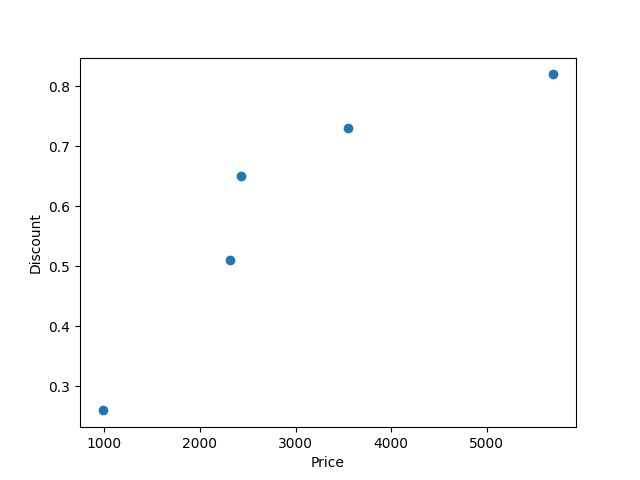

In [ ]:
let exe_path = r"D:\Programs\miniconda3\envs\cellpy\python.exe";
let df1 = df![
    "Model" => ["S1", "M1", "R2", "P8", "M4", "T5", "V1"],
    "Price" => [2430, 3550, 5700, 8750, 2315, 3560, 980],
    "Discount" => [Some(0.65), Some(0.73), Some(0.82), None, Some(0.51), None, Some(0.26)],
].unwrap();

let raw_plotting_code = r#"
import matplotlib.pyplot as plt

plt.scatter(df1["Price"], df1["Discount"])
plt.xlabel("Price")
plt.ylabel("Discount")
"#;

Plot::<Matplotlib>::build(data!(&df1)?)?
    .with_exe_path(exe_path)?
    .with_plotting_code(raw_plotting_code)
    .show()?;

In [ ]:
let exe_path = r"D:\Programs\miniconda3\envs\cellpy\python.exe";
let df1 = df![
    "Model" => ["S1", "M1", "R2", "P8", "M4", "T5", "V1"],
    "Price" => [2430, 3550, 5700, 8750, 2315, 3560, 980],
    "Discount" => [Some(0.65), Some(0.73), Some(0.82), None, Some(0.51), None, Some(0.26)],
].unwrap();

let raw_plotting_code = r#"
import matplotlib.pyplot as plt

plt.scatter(df1["Price"], df1["Discount"])
plt.xlabel("Price")
plt.ylabel("Discount")
"#;

Plot::<Matplotlib>::build(data!(&df1)?)?
    .with_exe_path(exe_path)?
    .with_plotting_code(raw_plotting_code)
    .save("matplotlib1.png")?;